In [1]:
# All dependencies are pre-installed on Colab
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time
import json
import os
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


---
## Part 1: Mess3 Data Generation

In [2]:
BOS_TOKEN = 3
VOCAB_SIZE = 4  # {0, 1, 2, BOS}


def build_mess3_matrices(alpha, x):
    """Build the 3 token-labelled transition matrices for a Mess3 process.
    Returns T: (3, 3, 3) array where T[token, from_state, to_state]."""
    b = (1 - alpha) / 2
    y = 1 - 2 * x
    T = np.zeros((3, 3, 3), dtype=np.float64)
    T[0] = [[alpha*y, b*x,     b*x],
            [alpha*x, b*y,     b*x],
            [alpha*x, b*x,     b*y]]
    T[1] = [[b*y,     alpha*x, b*x],
            [b*x,     alpha*y, b*x],
            [b*x,     alpha*x, b*y]]
    T[2] = [[b*y,     b*x,     alpha*x],
            [b*x,     b*y,     alpha*x],
            [b*x,     b*x,     alpha*y]]
    return T


# Build transition matrices for the 3 processes
PROCESS_PARAMS = [(0.5, 0.1), (0.8, 0.3), (0.6, 0.05)]
# T_all[k] = (3, 3, 3) transition matrices for process k
T_ALL = [build_mess3_matrices(a, x) for a, x in PROCESS_PARAMS]

# Precompute joint distribution tables: JOINT[k][s] = (9,) flattened joint over (token, next_state)
# and the CDF for fast sampling
JOINT_CDF = []  # JOINT_CDF[k] = (3, 9) cumulative distribution for each state
for k in range(3):
    cdf_k = np.zeros((3, 9), dtype=np.float64)
    for s in range(3):
        joint = np.array([T_ALL[k][tok][s, :] for tok in range(3)]).ravel()
        joint /= joint.sum()
        cdf_k[s] = np.cumsum(joint)
    JOINT_CDF.append(cdf_k)


def generate_dataset_batched(n_sequences, seq_length=15, seed=42):
    """Vectorised dataset generation. Generates all sequences for each component
    in batch, using vectorised CDF inversion instead of per-sequence Python loops.
    ~50-100x faster than the naive loop version."""
    rng = np.random.default_rng(seed)
    K = 3
    total_len = seq_length + 1  # BOS + content

    # Assign components
    all_components = rng.integers(0, K, size=n_sequences)
    all_tokens = np.empty((n_sequences, total_len), dtype=np.int64)
    all_tokens[:, 0] = BOS_TOKEN
    all_beliefs = np.empty((n_sequences, total_len, 3), dtype=np.float64)
    all_beliefs[:, 0, :] = 1.0 / 3.0  # prior

    for k in range(K):
        mask = all_components == k
        nk = mask.sum()
        if nk == 0:
            continue

        T_k = T_ALL[k]           # (3, 3, 3)
        cdf_k = JOINT_CDF[k]     # (3, 9)

        # Initial hidden states: uniform over {0,1,2}
        states = rng.integers(0, 3, size=nk)
        tokens_k = np.empty((nk, seq_length), dtype=np.int64)

        # Belief tracking: eta (nk, 3) row vectors
        eta = np.full((nk, 3), 1.0/3.0, dtype=np.float64)
        beliefs_k = np.empty((nk, seq_length + 1, 3), dtype=np.float64)
        beliefs_k[:, 0, :] = eta

        # Generate sequence step by step (15 steps, but vectorised over all nk sequences)
        for t in range(seq_length):
            # For each sequence, sample from joint(token, next_state) given current state
            # cdf_k[states] -> (nk, 9) CDF rows
            u = rng.random(nk)
            cdf_rows = cdf_k[states]  # (nk, 9)
            # Vectorised searchsorted: find idx such that cdf_rows[i, idx] >= u[i]
            idx = (cdf_rows < u[:, None]).sum(axis=1)  # (nk,)
            idx = np.clip(idx, 0, 8)
            tok = idx // 3
            next_state = idx % 3

            tokens_k[:, t] = tok
            states = next_state

            # Batch belief update: eta = eta @ T_k[tok]
            # T_k[tok] selects a (3,3) matrix per sequence -> (nk, 3, 3)
            T_sel = T_k[tok]  # (nk, 3, 3)
            eta = np.einsum('ni,nij->nj', eta, T_sel)
            eta /= eta.sum(axis=1, keepdims=True)
            beliefs_k[:, t + 1, :] = eta

        all_tokens[mask, 1:] = tokens_k
        all_beliefs[mask] = beliefs_k

    return {"tokens": all_tokens, "components": all_components, "beliefs": all_beliefs}


def compute_all_beliefs_and_posteriors_batched(tokens, components):
    """Vectorised belief & posterior computation for the analysis set.
    Processes all sequences in batch per component, ~50x faster."""
    K = 3
    N, L_total = tokens.shape
    seq_length = L_total - 1

    per_comp_beliefs = np.zeros((N, L_total, K, 3), dtype=np.float64)
    cum_lls = np.zeros((N, L_total, K), dtype=np.float64)

    content_tokens = tokens[:, 1:]  # (N, seq_length)

    for k in range(K):
        T_k = T_ALL[k]  # (3, 3, 3)
        eta = np.full((N, 3), 1.0/3.0, dtype=np.float64)
        per_comp_beliefs[:, 0, k, :] = eta
        # cum_lls[:, 0, k] = 0.0 already

        for t in range(seq_length):
            tok_t = content_tokens[:, t]  # (N,)
            T_sel = T_k[tok_t]            # (N, 3, 3)
            unnorm = np.einsum('ni,nij->nj', eta, T_sel)  # (N, 3)
            p_tok = unnorm.sum(axis=1)    # (N,)
            cum_lls[:, t + 1, k] = cum_lls[:, t, k] + np.log(p_tok + 1e-300)
            eta = unnorm / p_tok[:, None]
            per_comp_beliefs[:, t + 1, k, :] = eta

    # Posterior P(k | x_{1:ell}) at each position via Bayes rule
    # cum_lls: (N, L_total, K)
    log_probs = cum_lls - cum_lls.max(axis=2, keepdims=True)  # (N, L_total, K)
    probs = np.exp(log_probs)
    posteriors = probs / probs.sum(axis=2, keepdims=True)

    # True beliefs: select the generating component's beliefs
    # per_comp_beliefs[i, pos, k, :] -> select k = components[i]
    true_beliefs = per_comp_beliefs[np.arange(N), :, components, :]  # (N, L_total, 3)

    return {"per_component_beliefs": per_comp_beliefs, "posteriors": posteriors, "true_beliefs": true_beliefs}

In [3]:
N_TRAIN = 500_000
N_ANALYSIS = 50_000
SEQ_LENGTH = 15

print("Generating training set (vectorised)...")
t0 = time.time()
train_data = generate_dataset_batched(N_TRAIN, SEQ_LENGTH, seed=SEED)
print(f"  tokens: {train_data['tokens'].shape}, components: {np.bincount(train_data['components'])}")
print(f"  Time: {time.time()-t0:.1f}s")

print("\nGenerating analysis set (vectorised)...")
t0 = time.time()
analysis_data = generate_dataset_batched(N_ANALYSIS, SEQ_LENGTH, seed=SEED+1)
print(f"  tokens: {analysis_data['tokens'].shape}")
print(f"  Time: {time.time()-t0:.1f}s")

print("\nComputing beliefs & posteriors for analysis set (vectorised)...")
t0 = time.time()
belief_data = compute_all_beliefs_and_posteriors_batched(
    analysis_data["tokens"], analysis_data["components"]
)
print(f"  per_component_beliefs: {belief_data['per_component_beliefs'].shape}")
print(f"  posteriors: {belief_data['posteriors'].shape}")
print(f"  Time: {time.time()-t0:.1f}s")

Generating training set (vectorised)...
  tokens: (500000, 16), components: [166720 166371 166909]
  Time: 1.7s

Generating analysis set (vectorised)...
  tokens: (50000, 16)
  Time: 0.2s

Computing beliefs & posteriors for analysis set (vectorised)...
  per_component_beliefs: (50000, 16, 3, 3)
  posteriors: (50000, 16, 3)
  Time: 0.4s


---
## Part 2: Model Architecture & Training

In [4]:
@dataclass
class TransformerConfig:
    n_layers: int = 2
    d_model: int = 32
    d_mlp: int = 128
    n_heads: int = 2
    d_head: int = 16
    n_ctx: int = 16
    d_vocab: int = 4
    act_fn: str = "gelu"


class Attention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_Q = nn.Linear(cfg.d_model, cfg.n_heads * cfg.d_head, bias=False)
        self.W_K = nn.Linear(cfg.d_model, cfg.n_heads * cfg.d_head, bias=False)
        self.W_V = nn.Linear(cfg.d_model, cfg.n_heads * cfg.d_head, bias=False)
        self.W_O = nn.Linear(cfg.n_heads * cfg.d_head, cfg.d_model, bias=False)
        self.register_buffer("mask", torch.tril(torch.ones(cfg.n_ctx, cfg.n_ctx)).unsqueeze(0).unsqueeze(0))

    def forward(self, x):
        B, T, _ = x.shape
        nh, dh = self.cfg.n_heads, self.cfg.d_head
        Q = self.W_Q(x).view(B, T, nh, dh).transpose(1, 2)
        K = self.W_K(x).view(B, T, nh, dh).transpose(1, 2)
        V = self.W_V(x).view(B, T, nh, dh).transpose(1, 2)
        attn = (Q @ K.transpose(-2, -1)) / math.sqrt(dh)
        attn = attn.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        attn = F.softmax(attn, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, T, nh * dh)
        return self.W_O(out)


class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg.d_model, cfg.d_mlp)
        self.fc2 = nn.Linear(cfg.d_mlp, cfg.d_model)
        self.act_fn = F.gelu if cfg.act_fn == "gelu" else F.relu

    def forward(self, x):
        return self.fc2(self.act_fn(self.fc1(x)))


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = Attention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.mlp = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class HookedTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embed = nn.Embedding(cfg.d_vocab, cfg.d_model)
        self.pos_embed = nn.Embedding(cfg.n_ctx, cfg.d_model)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_final = nn.LayerNorm(cfg.d_model)
        self.unembed = nn.Linear(cfg.d_model, cfg.d_vocab, bias=False)
        self.hook_cache = {}
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() >= 2:
                nn.init.normal_(p, mean=0.0, std=0.02)

    def forward(self, input_ids, store_hooks=False):
        B, T = input_ids.shape
        positions = torch.arange(T, device=input_ids.device).unsqueeze(0)
        tok_emb = self.embed(input_ids)
        pos_emb = self.pos_embed(positions)
        if store_hooks:
            self.hook_cache = {}
            self.hook_cache["hook_embed"] = tok_emb.detach()
            self.hook_cache["hook_pos_embed"] = pos_emb.expand(B, -1, -1).detach()
        x = tok_emb + pos_emb
        for i, block in enumerate(self.blocks):
            x = block(x)
            if store_hooks:
                self.hook_cache[f"blocks.{i}.hook_resid_post"] = x.detach()
        x = self.ln_final(x)
        return self.unembed(x)

    def get_residual_stream(self, input_ids, layer):
        self.forward(input_ids, store_hooks=True)
        if layer == -1:
            return self.hook_cache["hook_embed"] + self.hook_cache["hook_pos_embed"]
        return self.hook_cache[f"blocks.{layer}.hook_resid_post"]

In [5]:
# Training
MODEL_CFG = TransformerConfig(
    n_layers=2, d_model=32, d_mlp=128, n_heads=2,
    d_head=16, n_ctx=16, d_vocab=4, act_fn="gelu"
)
N_STEPS = 5000
BATCH_SIZE = 1024
LR = 5e-4
CHECKPOINT_STEPS = {0, 100, 500, 1000, 2000, 5000}

torch.manual_seed(SEED)
np.random.seed(SEED)

model = HookedTransformer(MODEL_CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_CFG.n_layers} layers, {n_params:,} parameters, device={DEVICE}")

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
rng = np.random.default_rng(SEED)
train_tokens = train_data["tokens"]

losses_log = []
steps_log = []
checkpoints = {}

# Save init checkpoint
checkpoints[0] = {k: v.cpu().clone() for k, v in model.state_dict().items()}

step = 0
t0 = time.time()
while step < N_STEPS:
    indices = rng.permutation(len(train_tokens))
    for start in range(0, len(train_tokens), BATCH_SIZE):
        if step >= N_STEPS:
            break
        end = min(start + BATCH_SIZE, len(train_tokens))
        batch = torch.tensor(train_tokens[indices[start:end]], dtype=torch.long, device=DEVICE)
        input_ids = batch[:, :-1]
        targets = batch[:, 1:]

        logits = model(input_ids)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step += 1
        cl = loss.item()
        losses_log.append(cl)
        steps_log.append(step)

        if step % 500 == 0 or step == 1:
            print(f"  step {step:5d} | loss {cl:.4f} | {time.time()-t0:.1f}s")

        if step in CHECKPOINT_STEPS:
            checkpoints[step] = {k: v.cpu().clone() for k, v in model.state_dict().items()}

print(f"\nTraining done in {time.time()-t0:.1f}s. Final loss: {losses_log[-1]:.4f}")

Model: 2 layers, 25,984 parameters, device=cuda
  step     1 | loss 1.4279 | 0.8s
  step   500 | loss 1.0932 | 4.1s
  step  1000 | loss 1.0897 | 7.8s
  step  1500 | loss 1.0904 | 10.9s
  step  2000 | loss 1.0908 | 14.0s
  step  2500 | loss 1.0909 | 17.1s
  step  3000 | loss 1.0893 | 20.8s
  step  3500 | loss 1.0887 | 23.9s
  step  4000 | loss 1.0874 | 27.0s
  step  4500 | loss 1.0900 | 30.3s
  step  5000 | loss 1.0896 | 33.8s

Training done in 33.8s. Final loss: 1.0896


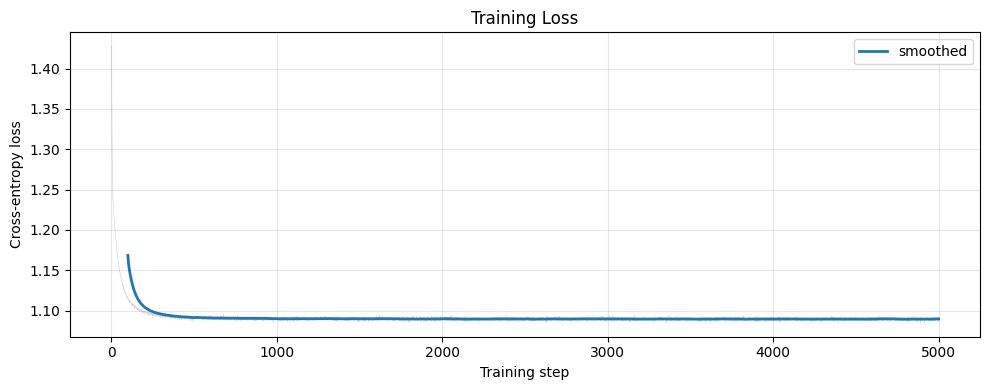

In [6]:
# Plot: Training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps_log, losses_log, linewidth=0.5, alpha=0.3, color="gray")
window = 100
kernel = np.ones(window) / window
smoothed = np.convolve(losses_log, kernel, mode="valid")
ax.plot(steps_log[window-1:], smoothed, linewidth=2, color="C0", label="smoothed")
ax.set_xlabel("Training step"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training Loss"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Part 3a: Cumulative Explained Variance (CEV)

In [7]:
# Helper: extract activations
def extract_activations(model, tokens, layer, device=DEVICE, batch_size=512):
    model.eval()
    all_acts = []
    with torch.no_grad():
        for start in range(0, len(tokens), batch_size):
            end = min(start + batch_size, len(tokens))
            batch = torch.tensor(tokens[start:end, :-1], dtype=torch.long, device=device)
            acts = model.get_residual_stream(batch, layer)
            all_acts.append(acts.cpu().numpy())
    return np.concatenate(all_acts, axis=0)

# Subsample for analysis
N_SUB = 10_000
sub_idx = np.random.default_rng(SEED).choice(len(analysis_data["tokens"]), N_SUB, replace=False)
tokens_sub = analysis_data["tokens"][sub_idx]
components_sub = analysis_data["components"][sub_idx]
per_comp_sub = belief_data["per_component_beliefs"][sub_idx]
posteriors_sub = belief_data["posteriors"][sub_idx]
true_beliefs_sub = belief_data["true_beliefs"][sub_idx]

# Extract activations at each layer
layer_indices = [-1, 0, 1]  # input, layer 0, layer 1
layer_names = ["Input (embed)", "Layer 0", "Layer 1"]

print("Extracting activations...")
acts_by_layer = {}
for layer in layer_indices:
    acts_by_layer[layer] = extract_activations(model, tokens_sub, layer)
    print(f"  layer {layer}: {acts_by_layer[layer].shape}")

Extracting activations...
  layer -1: (10000, 15, 32)
  layer 0: (10000, 15, 32)
  layer 1: (10000, 15, 32)


Input (embed): eff_dim(95%)=7
Layer 0: eff_dim(95%)=3
Layer 1: eff_dim(95%)=3


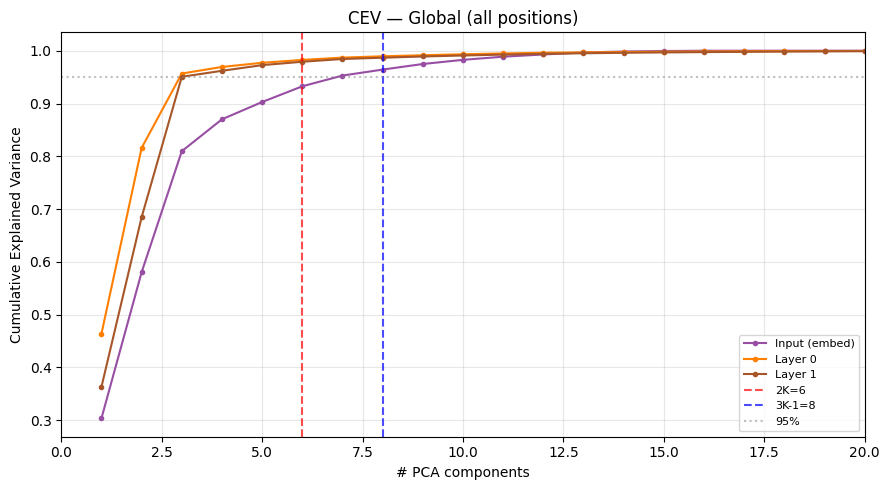

In [8]:
K = 3
LAYER_COLORS = ["#984ea3", "#ff7f00", "#a65628", "#f781bf"]
COMP_COLORS = ["#e41a1c", "#377eb8", "#4daf4a"]

# Global CEV
fig, ax = plt.subplots(figsize=(9, 5))
for i, (layer, name) in enumerate(zip(layer_indices, layer_names)):
    X = acts_by_layer[layer].reshape(-1, MODEL_CFG.d_model)
    pca = PCA(n_components=MODEL_CFG.d_model); pca.fit(X)
    cev = np.cumsum(pca.explained_variance_ratio_)
    ax.plot(range(1, len(cev)+1), cev, marker="o", ms=3, label=name, color=LAYER_COLORS[i])
    eff = int(np.searchsorted(cev, 0.95) + 1)
    print(f"{name}: eff_dim(95%)={eff}")

ax.axvline(x=2*K, color="red", ls="--", alpha=0.7, label=f"2K={2*K}")
ax.axvline(x=3*K-1, color="blue", ls="--", alpha=0.7, label=f"3K-1={3*K-1}")
ax.axhline(y=0.95, color="gray", ls=":", alpha=0.5, label="95%")
ax.set_xlabel("# PCA components"); ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("CEV — Global (all positions)"); ax.legend(fontsize=8)
ax.grid(True, alpha=0.3); ax.set_xlim(0, 20)
plt.tight_layout(); plt.show()

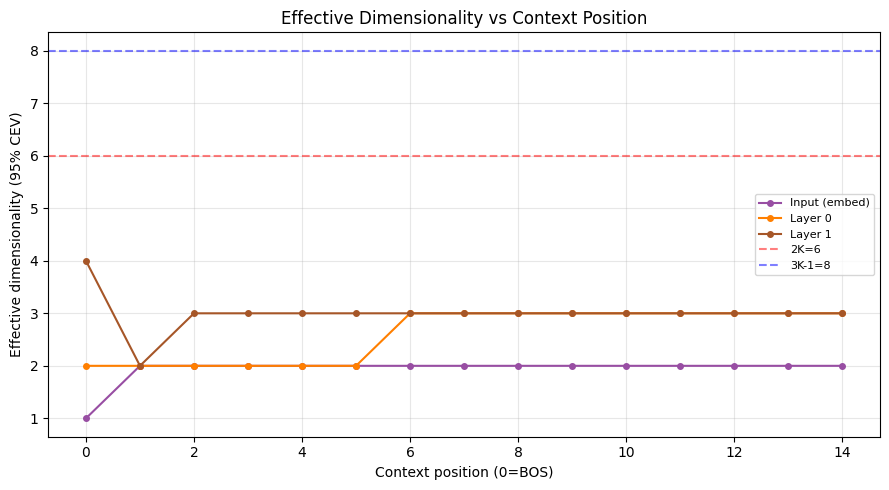

In [9]:
# Effective dimensionality vs context position
fig, ax = plt.subplots(figsize=(9, 5))
for i, (layer, name) in enumerate(zip(layer_indices, layer_names)):
    acts = acts_by_layer[layer]
    N, T, D = acts.shape
    eff_dims = []
    for pos in range(T):
        X = acts[:, pos, :]
        pca = PCA(n_components=D); pca.fit(X)
        cev = np.cumsum(pca.explained_variance_ratio_)
        eff_dims.append(int(np.searchsorted(cev, 0.95) + 1))
    ax.plot(range(T), eff_dims, marker="o", ms=4, label=name, color=LAYER_COLORS[i])

ax.axhline(y=2*K, color="red", ls="--", alpha=0.5, label=f"2K={2*K}")
ax.axhline(y=3*K-1, color="blue", ls="--", alpha=0.5, label=f"3K-1={3*K-1}")
ax.set_xlabel("Context position (0=BOS)"); ax.set_ylabel("Effective dimensionality (95% CEV)")
ax.set_title("Effective Dimensionality vs Context Position")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

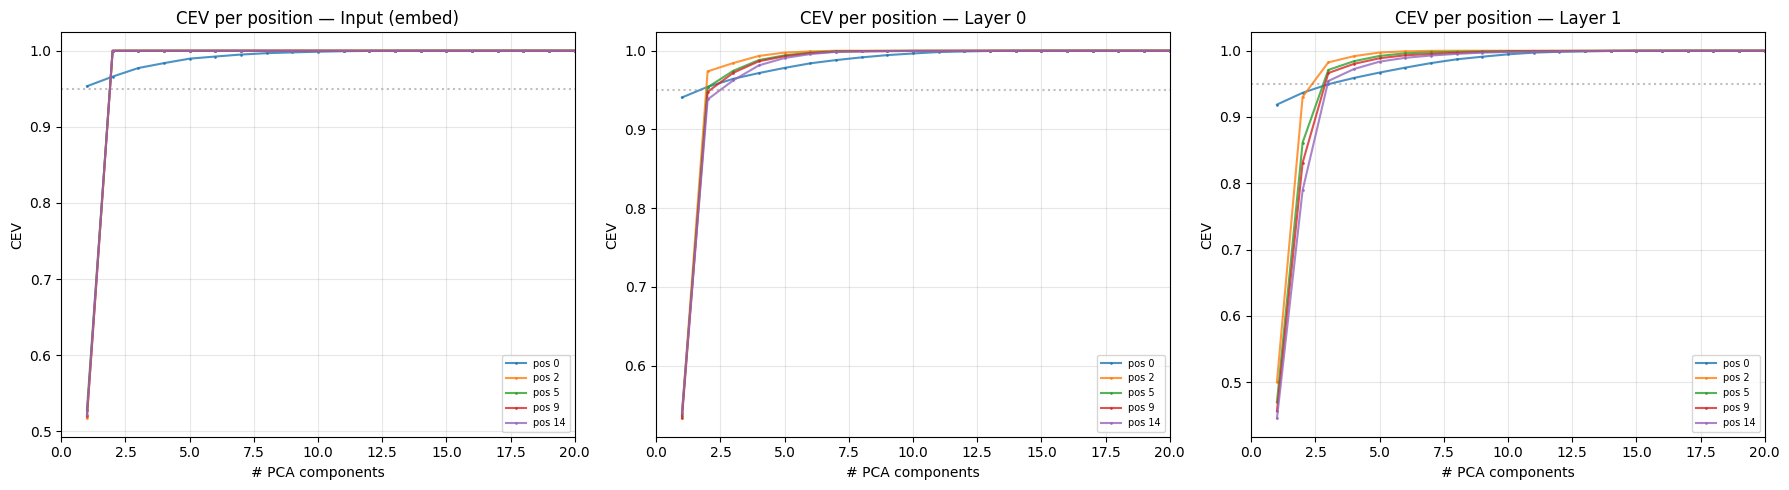

In [10]:
# CEV per position (selected positions, per layer)
selected_positions = [0, 2, 5, 9, 14]
fig, axes = plt.subplots(1, len(layer_indices), figsize=(6*len(layer_indices), 5))
for li, (layer, name) in enumerate(zip(layer_indices, layer_names)):
    ax = axes[li]
    acts = acts_by_layer[layer]
    for pos in selected_positions:
        X = acts[:, pos, :]
        pca = PCA(n_components=MODEL_CFG.d_model); pca.fit(X)
        cev = np.cumsum(pca.explained_variance_ratio_)
        ax.plot(range(1, len(cev)+1), cev, marker=".", ms=2, label=f"pos {pos}", alpha=0.8)
    ax.axhline(y=0.95, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("# PCA components"); ax.set_ylabel("CEV")
    ax.set_title(f"CEV per position — {name}")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_xlim(0, 20)
plt.tight_layout(); plt.show()

---
## Part 3b: Linear Regression to Belief States

In [11]:
def regression_analysis(activations, per_component_beliefs, posteriors, true_beliefs, positions=None):
    N, T, D = activations.shape
    _, L_total, K, _ = per_component_beliefs.shape
    if positions is None:
        positions = list(range(T))

    concat_rmse, true_rmse, posterior_rmse = [], [], []
    for pos in positions:
        X = activations[:, pos, :]
        y_concat = per_component_beliefs[:, pos, :, :].reshape(N, -1)
        y_true = true_beliefs[:, pos, :]
        y_post = posteriors[:, pos, :]

        for target, rmse_list in [(y_concat, concat_rmse), (y_true, true_rmse), (y_post, posterior_rmse)]:
            reg = Ridge(alpha=1e-4)
            reg.fit(X, target)
            pred = reg.predict(X)
            rmse_list.append(np.sqrt(np.mean((pred - target)**2)))

    return {"concat_rmse": concat_rmse, "true_rmse": true_rmse, "posterior_rmse": posterior_rmse, "positions": positions}


positions = list(range(acts_by_layer[0].shape[1]))
regression_by_layer = []

for layer, name in zip(layer_indices, layer_names):
    print(f"{name}: running regressions...")
    reg = regression_analysis(acts_by_layer[layer], per_comp_sub, posteriors_sub, true_beliefs_sub, positions)
    regression_by_layer.append(reg)
    for p in [0, 7, 14]:
        if p < len(reg["concat_rmse"]):
            print(f"  pos {p}: concat={reg['concat_rmse'][p]:.4f} true={reg['true_rmse'][p]:.4f} post={reg['posterior_rmse'][p]:.4f}")

Input (embed): running regressions...
  pos 0: concat=0.0000 true=0.0000 post=0.0000
  pos 7: concat=0.1304 true=0.1617 post=0.0701
  pos 14: concat=0.1312 true=0.1632 post=0.1091
Layer 0: running regressions...


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.98004e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.98004e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.98004e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.62354e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.62354e-09): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

  pos 0: concat=0.0000 true=0.0000 post=0.0000
  pos 7: concat=0.0139 true=0.1192 post=0.0286
  pos 14: concat=0.0170 true=0.1194 post=0.0761
Layer 1: running regressions...


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.24268e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.24268e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.24268e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.8112e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.8112e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3

  pos 0: concat=0.0000 true=0.0000 post=0.0000
  pos 7: concat=0.0138 true=0.1191 post=0.0172
  pos 14: concat=0.0182 true=0.1195 post=0.0434


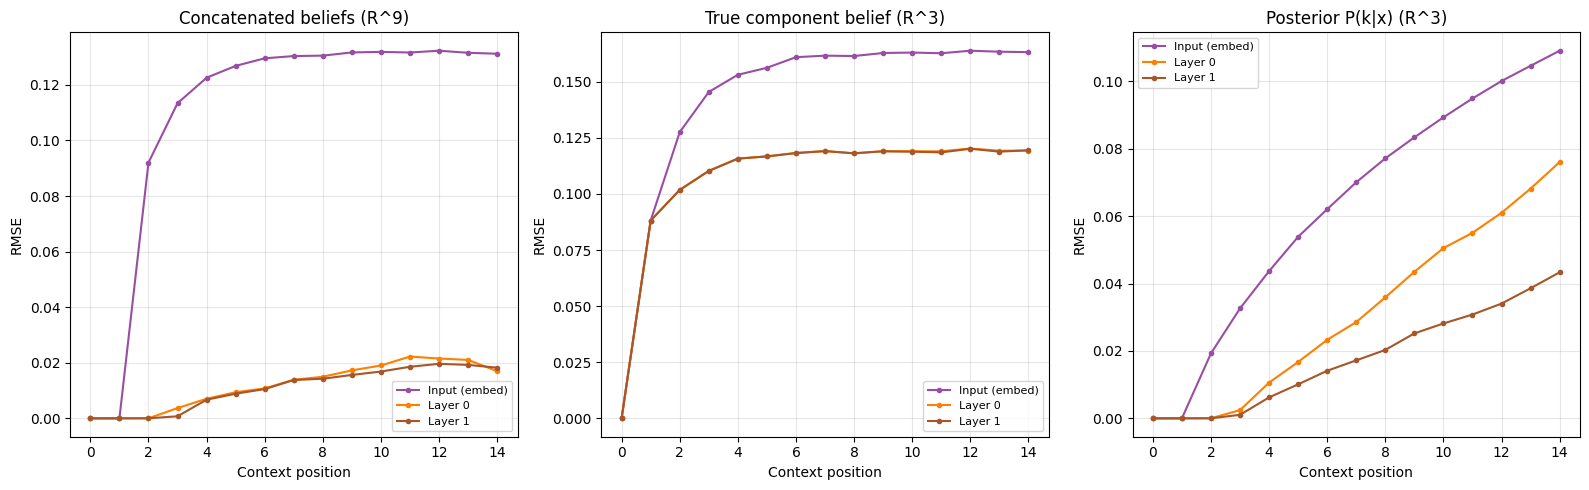

In [12]:
# Plot: Regression RMSE vs position
targets = ["concat_rmse", "true_rmse", "posterior_rmse"]
target_labels = ["Concatenated beliefs (R^9)", "True component belief (R^3)", "Posterior P(k|x) (R^3)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ti, (tkey, tlabel) in enumerate(zip(targets, target_labels)):
    ax = axes[ti]
    for li, (reg, name) in enumerate(zip(regression_by_layer, layer_names)):
        ax.plot(reg["positions"], reg[tkey], marker="o", ms=3, label=name, color=LAYER_COLORS[li])
    ax.set_xlabel("Context position"); ax.set_ylabel("RMSE")
    ax.set_title(tlabel); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Part 3c: Subspace Overlap & Additivity Test

In [13]:
def subspace_overlap(Q_A, Q_B):
    d_min = min(Q_A.shape[1], Q_B.shape[1])
    cross = Q_A.T @ Q_B
    return float(np.sum(cross**2) / d_min)


def per_component_subspaces(activations, components, position, n_dims=2):
    Kc = int(components.max()) + 1
    D = activations.shape[2]
    bases, eff_dims = [], []
    for k in range(Kc):
        X = activations[components == k, position, :]
        X = X - X.mean(axis=0)
        pca = PCA(n_components=min(D, X.shape[0])); pca.fit(X)
        bases.append(pca.components_[:n_dims].T)
        cev = np.cumsum(pca.explained_variance_ratio_)
        eff_dims.append(int(np.searchsorted(cev, 0.95) + 1))
    overlaps = np.zeros((Kc, Kc))
    for i in range(Kc):
        for j in range(Kc):
            overlaps[i, j] = subspace_overlap(bases[i], bases[j])
    return {"bases": bases, "eff_dims": eff_dims, "overlaps": overlaps}


def additivity_test(activations, components, position):
    Kc = int(components.max()) + 1
    D = activations.shape[2]
    per_comp_eff = []
    for k in range(Kc):
        X = activations[components == k, position, :]; X = X - X.mean(axis=0)
        pca = PCA(n_components=min(D, X.shape[0])); pca.fit(X)
        cev = np.cumsum(pca.explained_variance_ratio_)
        per_comp_eff.append(int(np.searchsorted(cev, 0.95) + 1))
    X_all = activations[:, position, :]; X_all = X_all - X_all.mean(axis=0)
    pca = PCA(n_components=min(D, X_all.shape[0])); pca.fit(X_all)
    cev = np.cumsum(pca.explained_variance_ratio_)
    union_eff = int(np.searchsorted(cev, 0.95) + 1)
    return {"per_component_eff_dims": per_comp_eff, "sum_per_component": sum(per_comp_eff), "union_eff_dim": union_eff}


# Analyse final layer
final_acts = acts_by_layer[1]  # Layer 1 (final)
selected_positions = [1, 5, 14]
overlaps_list, additivity_list = [], []

for pos in selected_positions:
    sub = per_component_subspaces(final_acts, components_sub, pos, n_dims=2)
    overlaps_list.append(sub["overlaps"])
    add = additivity_test(final_acts, components_sub, pos)
    additivity_list.append(add)
    print(f"Position {pos}: eff_dims={sub['eff_dims']}, additivity: sum={add['sum_per_component']}, union={add['union_eff_dim']}")
    print(f"  Overlaps:\n{sub['overlaps']}\n")

Position 1: eff_dims=[2, 2, 2], additivity: sum=6, union=2
  Overlaps:
[[0.99999994 1.         0.99999994]
 [1.         0.99999994 0.99999988]
 [0.99999994 0.99999988 1.        ]]

Position 5: eff_dims=[3, 3, 3], additivity: sum=9, union=3
  Overlaps:
[[0.99999988 0.9999088  0.9994027 ]
 [0.9999088  1.00000012 0.99943984]
 [0.99940276 0.99943984 0.99999994]]

Position 14: eff_dims=[3, 4, 3], additivity: sum=10, union=3
  Overlaps:
[[0.99999976 0.99928778 0.99660873]
 [0.99928778 1.         0.9975698 ]
 [0.99660861 0.99756974 1.        ]]



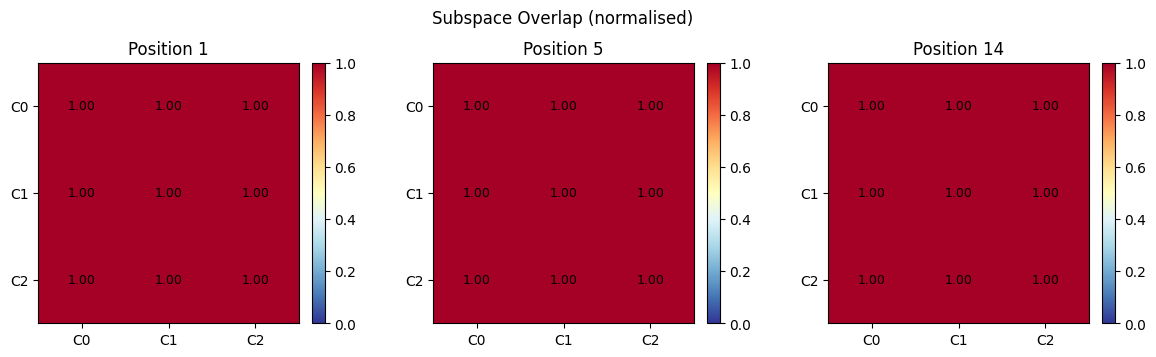

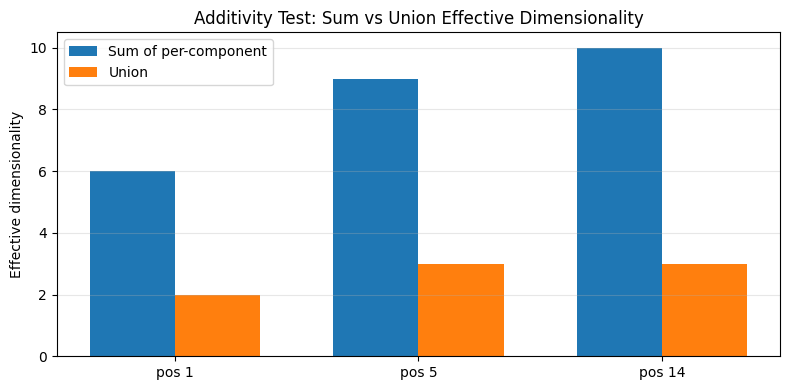

In [14]:
# Plot: Subspace overlap heatmaps
fig, axes = plt.subplots(1, len(selected_positions), figsize=(4*len(selected_positions), 3.5))
for i, (overlap, pos) in enumerate(zip(overlaps_list, selected_positions)):
    ax = axes[i]
    im = ax.imshow(overlap, vmin=0, vmax=1, cmap="RdYlBu_r")
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels([f"C{k}" for k in range(K)]); ax.set_yticklabels([f"C{k}" for k in range(K)])
    ax.set_title(f"Position {pos}")
    for ii in range(K):
        for jj in range(K):
            ax.text(jj, ii, f"{overlap[ii,jj]:.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Subspace Overlap (normalised)", fontsize=12)
plt.tight_layout(); plt.show()

# Plot: Additivity test
sums = [a["sum_per_component"] for a in additivity_list]
unions = [a["union_eff_dim"] for a in additivity_list]
x = np.arange(len(selected_positions)); width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, sums, width, label="Sum of per-component", color="C0")
ax.bar(x + width/2, unions, width, label="Union", color="C1")
ax.set_xticks(x); ax.set_xticklabels([f"pos {p}" for p in selected_positions])
ax.set_ylabel("Effective dimensionality")
ax.set_title("Additivity Test: Sum vs Union Effective Dimensionality")
ax.legend(); ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

---
## Part 3d: PCA Scatter Visualisation

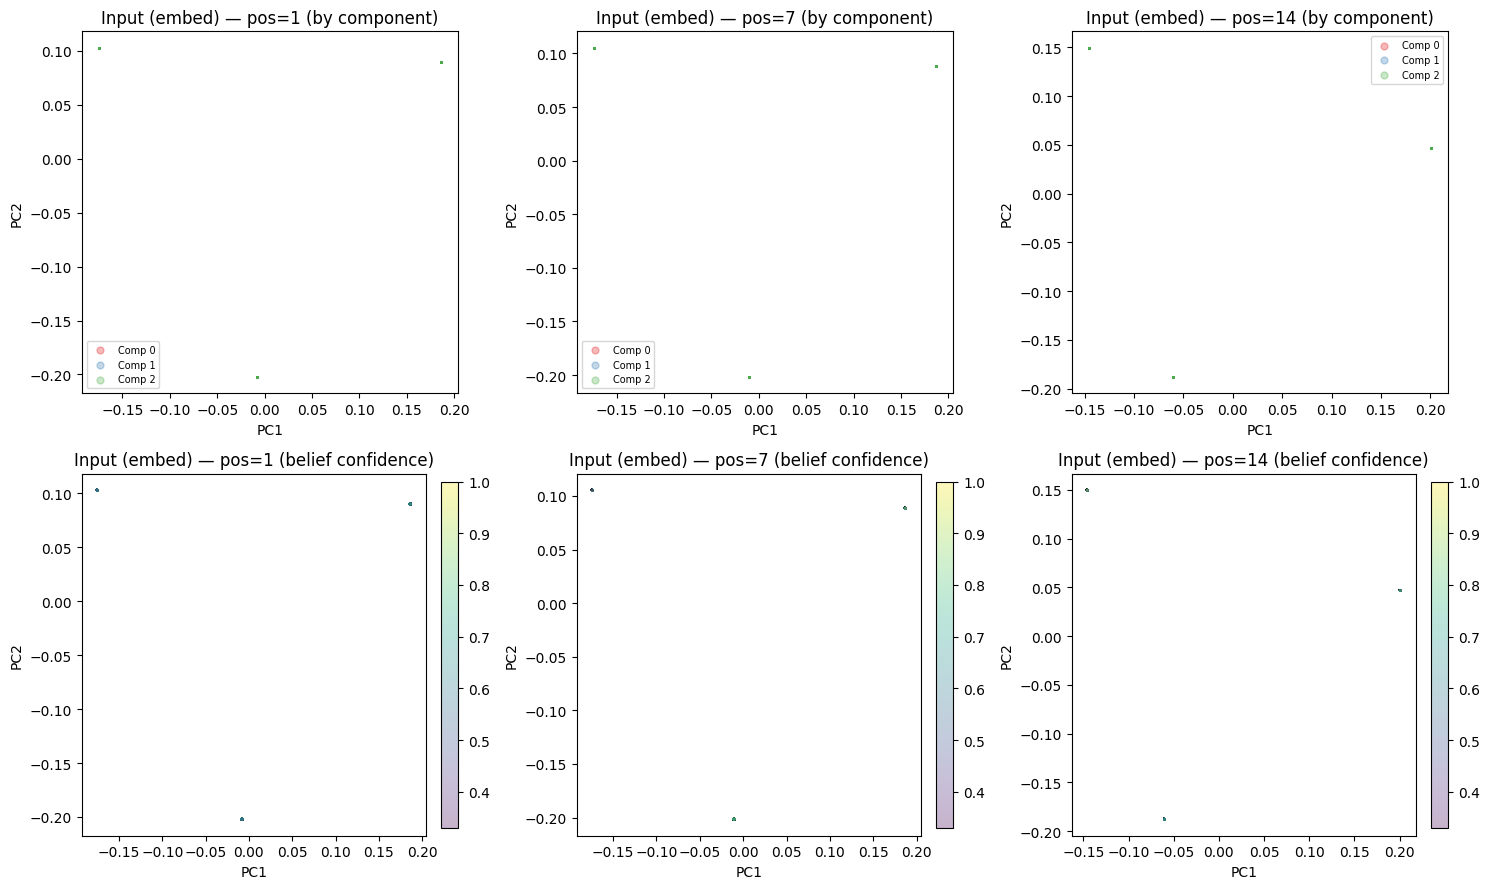

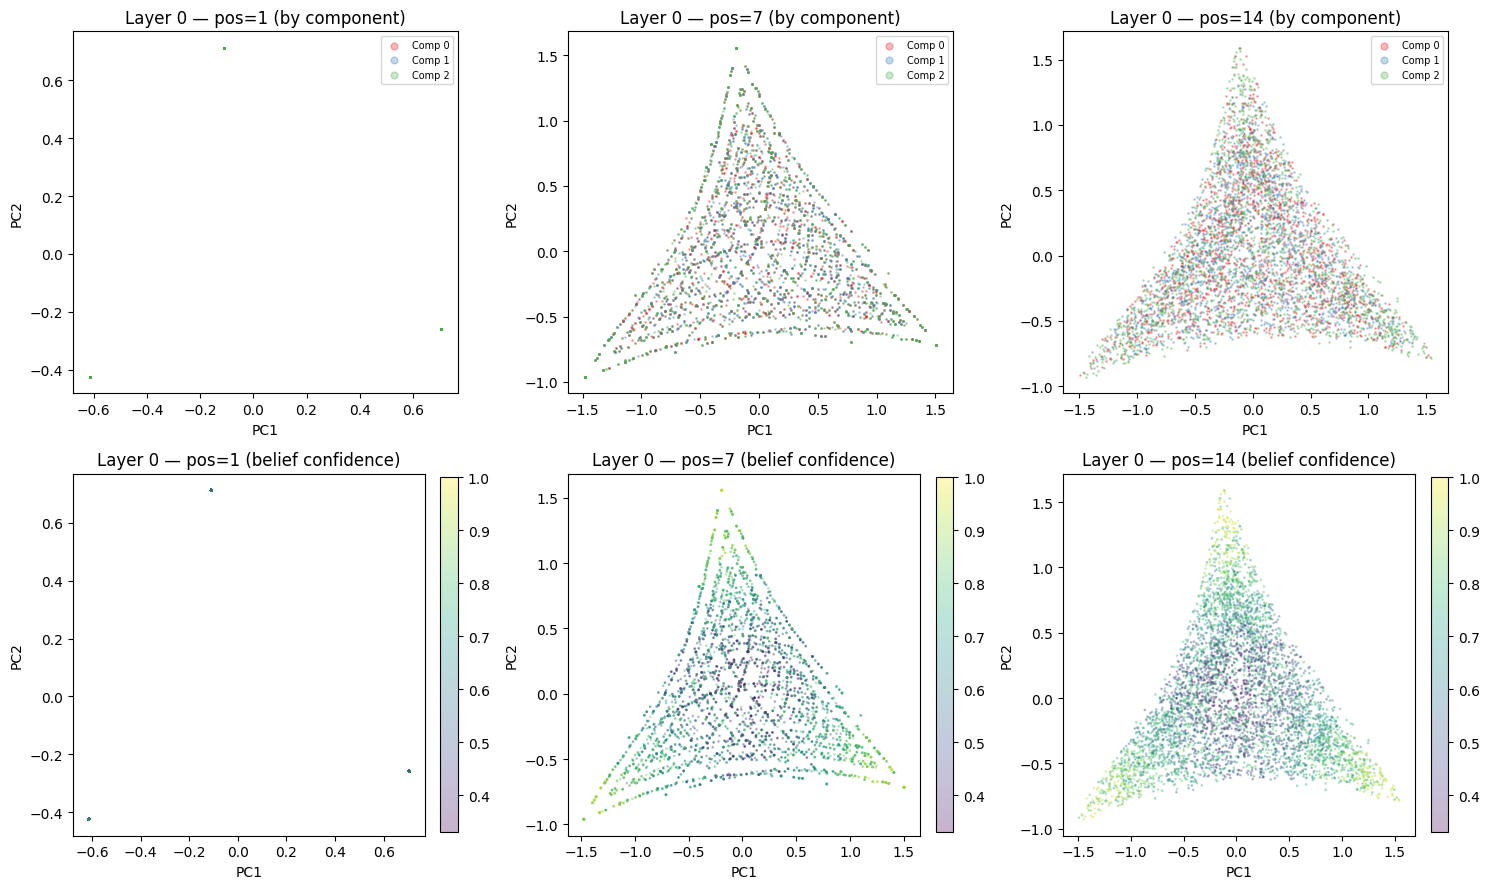

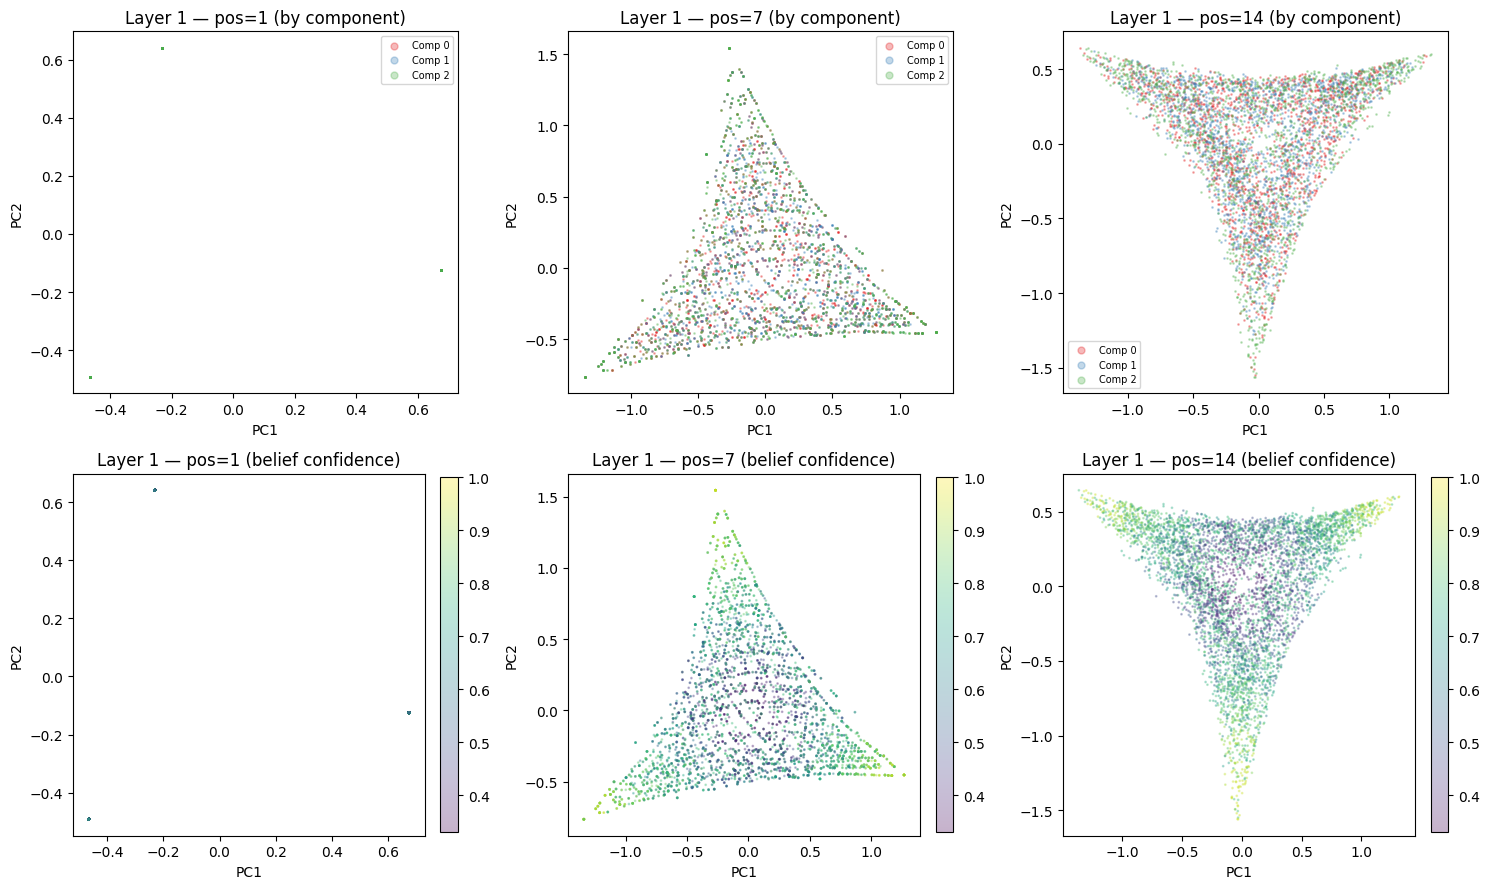

In [15]:
N_SCATTER = 5000
scatter_positions = [1, 7, 14]

for layer, name in zip(layer_indices, layer_names):
    acts = acts_by_layer[layer][:N_SCATTER]
    comps = components_sub[:N_SCATTER]
    tb = true_beliefs_sub[:N_SCATTER]

    fig, axes = plt.subplots(2, len(scatter_positions), figsize=(5*len(scatter_positions), 9))
    for pi, pos in enumerate(scatter_positions):
        X = acts[:, pos, :]
        pca = PCA(n_components=2); Z = pca.fit_transform(X)

        # Row 1: by component
        ax = axes[0, pi]
        for k in range(3):
            mask = comps == k
            ax.scatter(Z[mask, 0], Z[mask, 1], s=1, alpha=0.3, color=COMP_COLORS[k], label=f"Comp {k}")
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
        ax.set_title(f"{name} — pos={pos} (by component)")
        ax.legend(markerscale=5, fontsize=7)

        # Row 2: by belief confidence
        ax = axes[1, pi]
        conf = tb[:, pos, :].max(axis=1)
        sc = ax.scatter(Z[:, 0], Z[:, 1], s=1, alpha=0.3, c=conf, cmap="viridis", vmin=0.33, vmax=1.0)
        ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
        ax.set_title(f"{name} — pos={pos} (belief confidence)")
        fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout(); plt.show()